# Zeus MCMC Convergence Analysis: Full 10-Parameter Fit

This notebook analyzes the zeus MCMC chain for the DES Y3 cluster cosmology pipeline.

**Chain details:**
- Sampler: zeus (ensemble slice sampling)
- Walkers: 44
- Free parameters: 10 (5 cosmological + 5 scaling relation)
- Data: DES Y3 Cluster Cosmology (Buzzard v1.9.8 mock)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14

## 1. Load Chain Data

In [2]:
chain_file = 'zeus_full.txt'

# Load manually to skip corrupted lines (MPI write collisions)
good_lines = []
n_corrupted = 0
with open(chain_file) as f:
    for line in f:
        if line.startswith('#'):
            continue
        try:
            vals = [float(x) for x in line.strip().split('\t')]
            if len(vals) == 12:
                good_lines.append(vals)
            else:
                n_corrupted += 1
        except:
            n_corrupted += 1

data = np.array(good_lines)
print(f'Loaded chain: {data.shape[0]} good samples, {n_corrupted} corrupted lines skipped')

# Parameter names and labels
param_names = ['h0', 'omega_m', 'omega_b', 'log1e10as', 'n_s',
               'mor_logmmin', 'mor_logratio', 'mor_alpha', 'mor_sigma', 'mor_epsilon']
param_labels = [r'$h$', r'$\Omega_m$', r'$\Omega_b$', r'$\ln(10^{10}A_s)$', r'$n_s$',
                r'$\log M_{\rm min}$', r'$\log R$', r'$\alpha_{\rm MOR}$',
                r'$\sigma_{\rm MOR}$', r'$\epsilon_{\rm MOR}$']

cosmo_idx = [0, 1, 2, 3, 4]
mor_idx = [5, 6, 7, 8, 9]
cosmo_labels = [param_labels[i] for i in cosmo_idx]
mor_labels = [param_labels[i] for i in mor_idx]

# Chain configuration
n_walkers = 44
n_params = 10
n_samples = data.shape[0]
n_steps = n_samples // n_walkers

# Use only complete steps
usable = n_steps * n_walkers
data = data[:usable]

print(f'Walkers: {n_walkers}')
print(f'Complete steps: {n_steps}')
print(f'Usable samples: {usable}')

Loaded chain: 3296 good samples, 3 corrupted lines skipped
Walkers: 44
Complete steps: 74
Usable samples: 3256


In [3]:
# Reshape: (n_steps, n_walkers, n_cols)
chain = data[:, :n_params].reshape(n_steps, n_walkers, n_params)
log_post = data[:, -1].reshape(n_steps, n_walkers)

# Burn-in: discard first 20%
burn_in = n_steps // 5
print(f'Burn-in: {burn_in} steps ({burn_in * n_walkers} samples)')

chain_post = chain[burn_in:]
samples = chain_post.reshape(-1, n_params)
print(f'Post burn-in samples: {samples.shape[0]}')

Burn-in: 14 steps (616 samples)
Post burn-in samples: 2640


## 2. Trace Plots

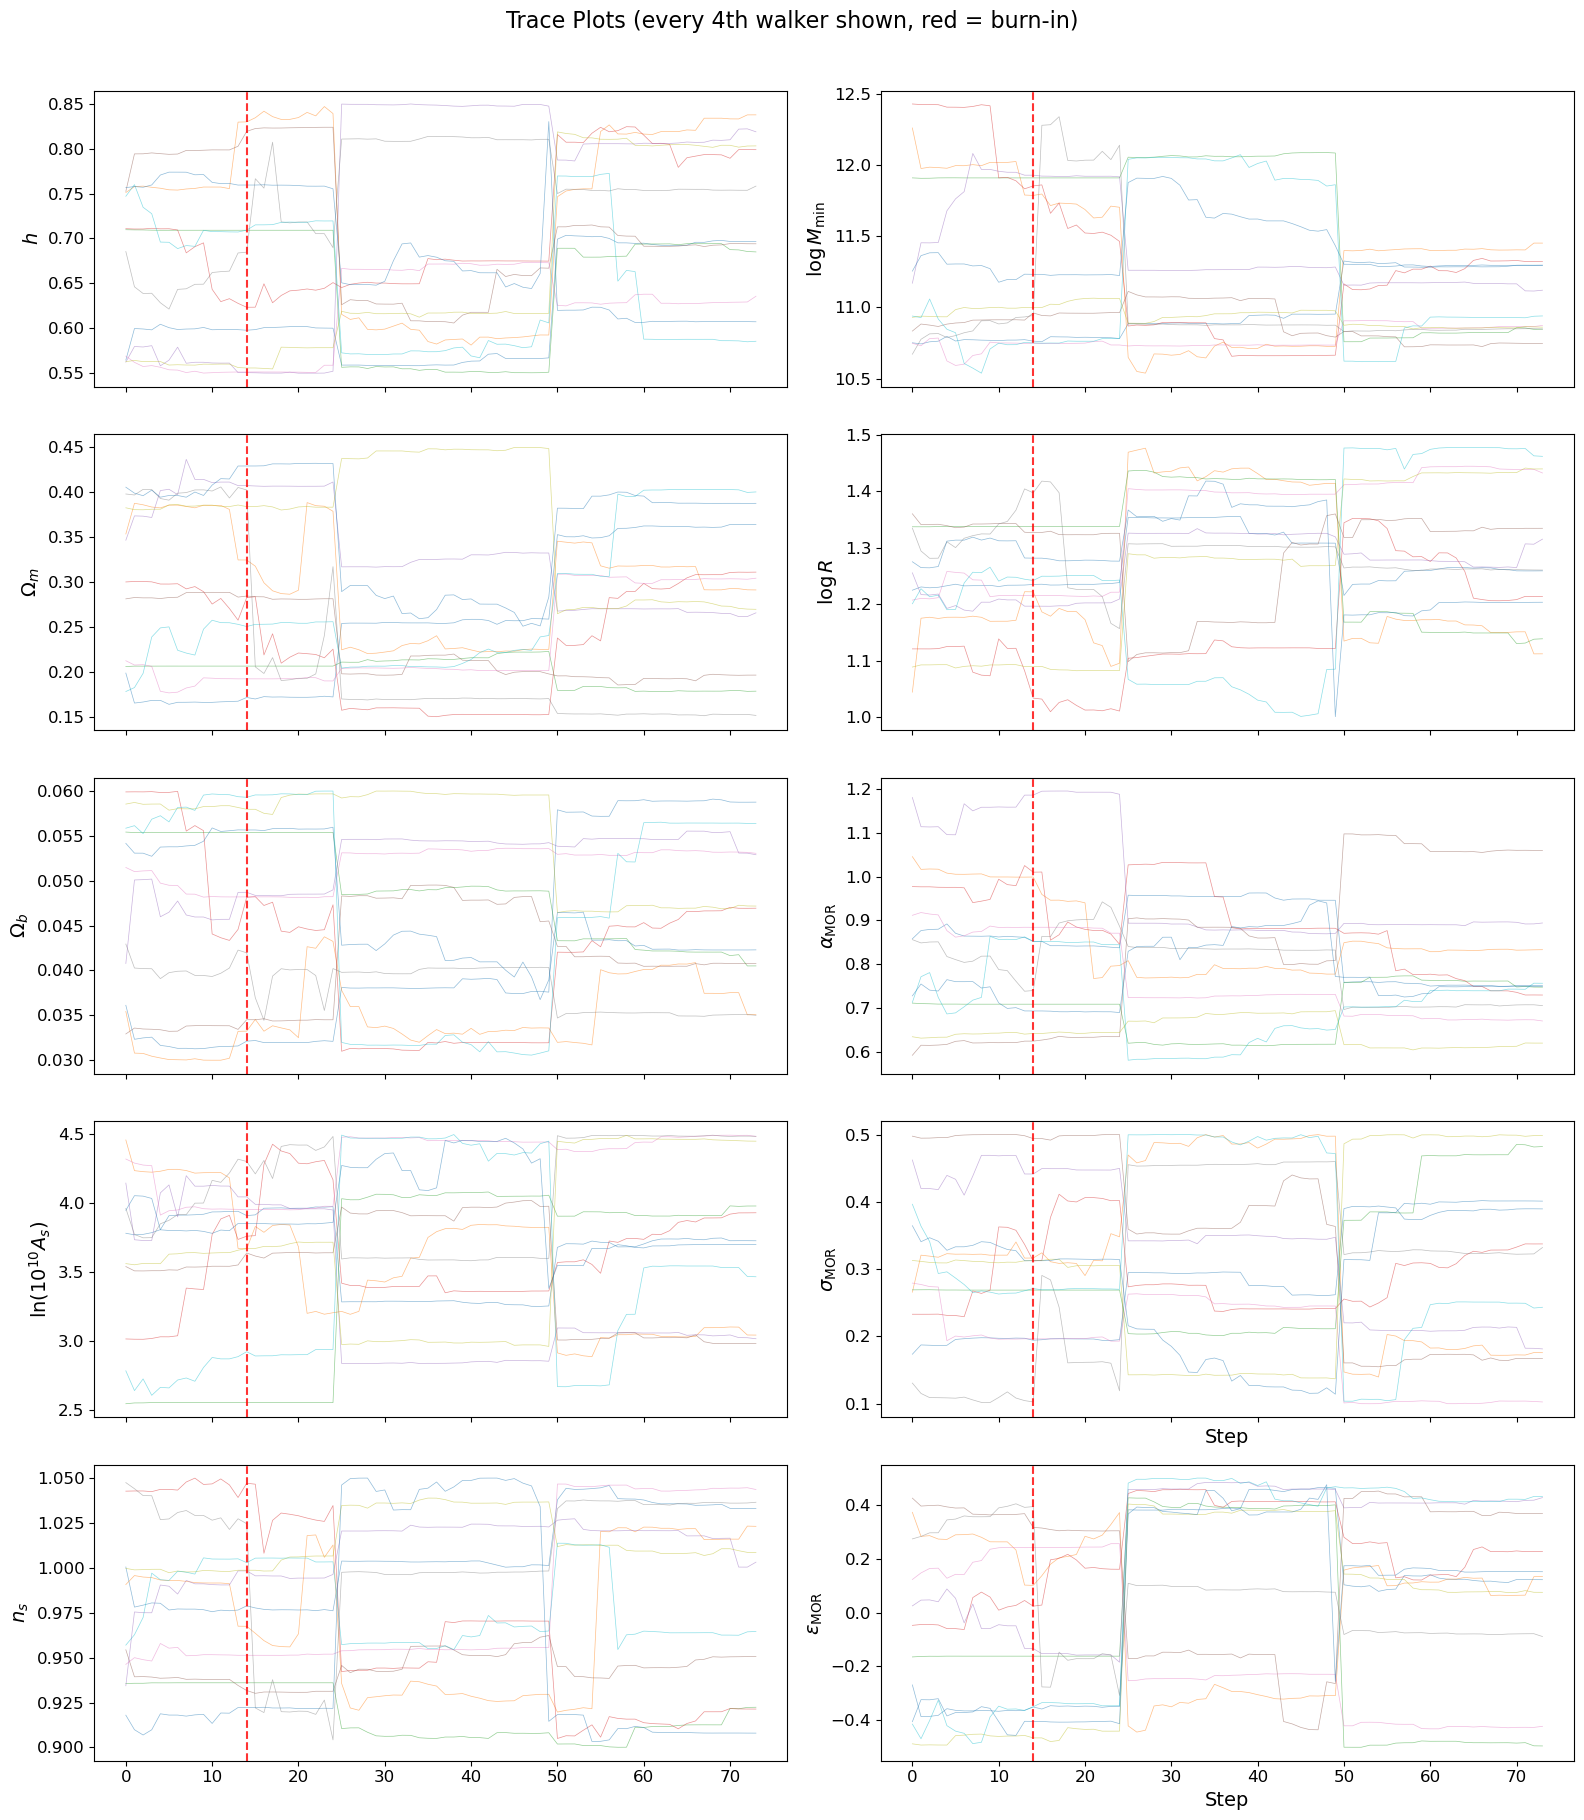

In [4]:
fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True)
axes = axes.T.flatten()  # column-major order

for i in range(n_params):
    ax = axes[i]
    for w in range(0, n_walkers, 4):  # plot every 4th walker to reduce clutter
        ax.plot(chain[:, w, i], alpha=0.5, lw=0.5)
    ax.axvline(burn_in, color='red', ls='--', lw=1.5, alpha=0.8)
    ax.set_ylabel(param_labels[i])
    if i >= n_params - 2:
        ax.set_xlabel('Step')

fig.suptitle('Trace Plots (every 4th walker shown, red = burn-in)', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('zeus_trace_plots.png', dpi=150, bbox_inches='tight')
plt.show()

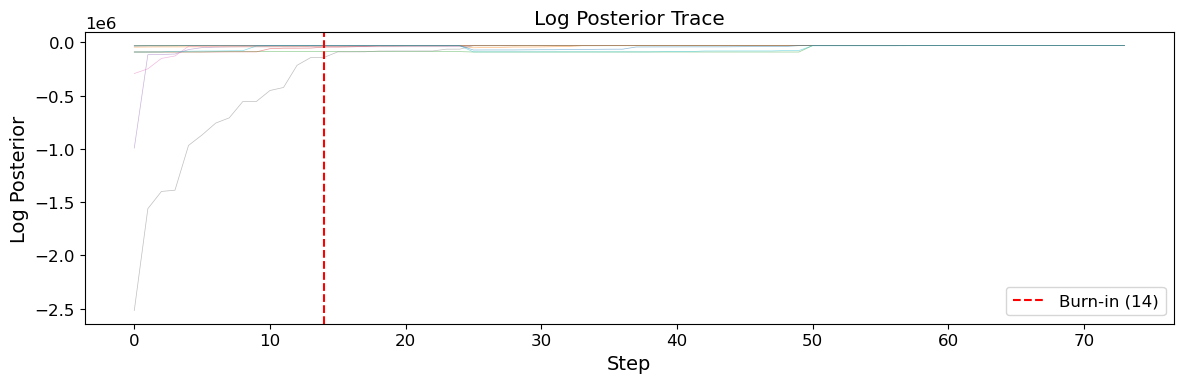

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
for w in range(0, n_walkers, 4):
    ax.plot(log_post[:, w], alpha=0.5, lw=0.5)
ax.axvline(burn_in, color='red', ls='--', lw=1.5, label=f'Burn-in ({burn_in})')
ax.set_xlabel('Step')
ax.set_ylabel('Log Posterior')
ax.set_title('Log Posterior Trace')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Convergence Diagnostics

### 3.1 Gelman-Rubin $\hat{R}$

In [6]:
def gelman_rubin(chains):
    """Compute R-hat. chains shape: (n_steps, n_chains)"""
    n_steps, n_chains = chains.shape
    chain_means = np.mean(chains, axis=0)
    chain_vars = np.var(chains, axis=0, ddof=1)
    W = np.mean(chain_vars)
    B = n_steps * np.var(chain_means, ddof=1)
    var_est = (1 - 1.0 / n_steps) * W + B / n_steps
    return np.sqrt(var_est / W) if W > 0 else np.inf

print('=== Gelman-Rubin R-hat (post burn-in) ===')
print(f'{"Parameter":>25s}  {"R-hat":>8s}  Status')
print('-' * 50)
rhat_values = []
for i in range(n_params):
    rhat = gelman_rubin(chain_post[:, :, i])
    rhat_values.append(rhat)
    status = 'OK' if rhat < 1.1 else 'NOT CONVERGED'
    print(f'{param_names[i]:>25s}  {rhat:8.4f}  {status}')

all_converged = all(r < 1.1 for r in rhat_values)
print(f'\nOverall: {"CONVERGED" if all_converged else "NOT CONVERGED"}')

=== Gelman-Rubin R-hat (post burn-in) ===
                Parameter     R-hat  Status
--------------------------------------------------
                       h0    1.2085  NOT CONVERGED
                  omega_m    1.2906  NOT CONVERGED
                  omega_b    1.2575  NOT CONVERGED
                log1e10as    1.3156  NOT CONVERGED
                      n_s    1.1773  NOT CONVERGED
              mor_logmmin    1.2131  NOT CONVERGED
             mor_logratio    1.1967  NOT CONVERGED
                mor_alpha    1.2174  NOT CONVERGED
                mor_sigma    1.3051  NOT CONVERGED
              mor_epsilon    1.2184  NOT CONVERGED

Overall: NOT CONVERGED


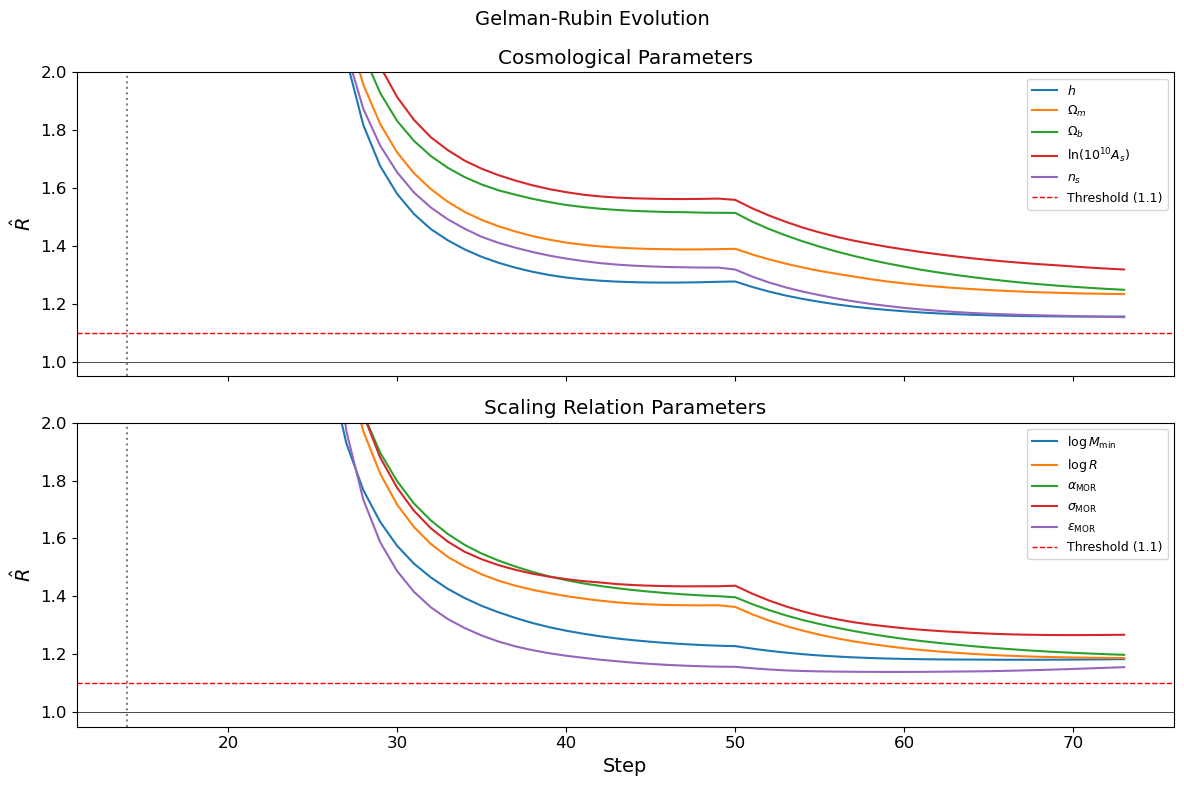

In [7]:
# R-hat evolution
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

min_steps = 20
step_range = np.arange(min_steps, n_steps, max(1, n_steps // 100))

for ax, idx_group, title in [(axes[0], cosmo_idx, 'Cosmological'),
                              (axes[1], mor_idx, 'Scaling Relation')]:
    for i in idx_group:
        rhat_evo = [gelman_rubin(chain[:s, :, i]) for s in step_range]
        ax.plot(step_range, rhat_evo, lw=1.5, label=param_labels[i])
    ax.axhline(1.0, color='k', ls='-', lw=0.5)
    ax.axhline(1.1, color='red', ls='--', lw=1, label='Threshold (1.1)')
    ax.axvline(burn_in, color='grey', ls=':', lw=1.5)
    ax.set_ylabel(r'$\hat{R}$')
    ax.set_title(f'{title} Parameters')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0.95, 2.0)

axes[1].set_xlabel('Step')
fig.suptitle('Gelman-Rubin Evolution', fontsize=14)
plt.tight_layout()
plt.savefig('zeus_gelman_rubin.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Autocorrelation & Effective Sample Size

In [8]:
def integrated_autocorr_time(x, c=5):
    """Estimate IAT using Sokal's method."""
    n = len(x)
    x = x - np.mean(x)
    acf = np.correlate(x, x, mode='full')[n-1:]
    acf = acf / acf[0]
    tau = 1.0
    for M in range(1, len(acf)):
        tau += 2 * acf[M]
        if M >= c * tau:
            break
    return max(tau, 1.0)

print('=== Effective Sample Size (post burn-in) ===')
print(f'{"Parameter":>25s}  {"IAT":>8s}  {"n_eff":>8s}')
print('-' * 50)

n_post = samples.shape[0]
for i in range(n_params):
    iat = integrated_autocorr_time(samples[:, i])
    n_eff = n_post / iat
    print(f'{param_names[i]:>25s}  {iat:8.1f}  {n_eff:8.0f}')

=== Effective Sample Size (post burn-in) ===
                Parameter       IAT     n_eff
--------------------------------------------------
                       h0       1.0      2640
                  omega_m       1.0      2640
                  omega_b       1.8      1460
                log1e10as       1.0      2640
                      n_s       1.0      2640
              mor_logmmin       1.0      2640
             mor_logratio       1.0      2640
                mor_alpha       1.3      2099
                mor_sigma       1.0      2640
              mor_epsilon       1.1      2299


## 4. Parameter Constraints

In [9]:
# Fiducial values from values_full.ini
fiducial = {'h0': 0.6726, 'omega_m': 0.3, 'omega_b': 0.045,
            'log1e10as': 3.044, 'n_s': 0.965,
            'mor_logmmin': 11.13, 'mor_logratio': 1.22,
            'mor_alpha': 0.75, 'mor_sigma': 0.2, 'mor_epsilon': 0.0}

print('=== Parameter Constraints (post burn-in) ===')
print(f'{"Parameter":>25s}  {"Mean":>10s}  {"Std":>10s}  {"Fiducial":>10s}  {"Bias (sigma)":>12s}')
print('-' * 75)
for i, p in enumerate(param_names):
    mean = np.mean(samples[:, i])
    std = np.std(samples[:, i])
    fid = fiducial[p]
    bias = (mean - fid) / std if std > 0 else 0
    print(f'{p:>25s}  {mean:10.5f}  {std:10.5f}  {fid:10.5f}  {bias:+10.2f} sigma')

=== Parameter Constraints (post burn-in) ===
                Parameter        Mean         Std    Fiducial  Bias (sigma)
---------------------------------------------------------------------------
                       h0     0.68699     0.09386     0.67260       +0.15 sigma
                  omega_m     0.29031     0.08365     0.30000       -0.12 sigma
                  omega_b     0.04443     0.00835     0.04500       -0.07 sigma
                log1e10as     3.64346     0.54475     3.04400       +1.10 sigma
                      n_s     0.97929     0.04406     0.96500       +0.32 sigma
              mor_logmmin    11.20018     0.41035    11.13000       +0.17 sigma
             mor_logratio     1.24611     0.13624     1.22000       +0.19 sigma
                mor_alpha     0.78777     0.13732     0.75000       +0.28 sigma
                mor_sigma     0.30576     0.11713     0.20000       +0.90 sigma
              mor_epsilon     0.01828     0.29194     0.00000       +0.06 sigma


## 5. Corner Plots

### 5.1 Cosmological Parameters

In [10]:
def corner_plot(samples, labels, fiducial_vals=None, title=None, filename=None):
    """Make a triangle/corner plot."""
    ndim = samples.shape[1]
    fig, axes = plt.subplots(ndim, ndim, figsize=(3 * ndim, 3 * ndim))

    for i in range(ndim):
        for j in range(ndim):
            ax = axes[i, j]
            if j > i:
                ax.set_visible(False)
                continue

            if i == j:
                # 1D histogram on diagonal
                ax.hist(samples[:, i], bins=50, density=True,
                        color='steelblue', alpha=0.7, edgecolor='none')
                kde = stats.gaussian_kde(samples[:, i])
                x_grid = np.linspace(samples[:, i].min(), samples[:, i].max(), 200)
                ax.plot(x_grid, kde(x_grid), 'k-', lw=1.5)
                if fiducial_vals is not None:
                    ax.axvline(fiducial_vals[i], color='red', ls='--', lw=1.5)
                ax.set_yticks([])
            else:
                # 2D contour
                H, xedges, yedges = np.histogram2d(
                    samples[:, j], samples[:, i], bins=50)
                H = gaussian_filter(H, sigma=1.5)
                # Compute levels for 68% and 95% contours
                H_sorted = np.sort(H.flatten())[::-1]
                H_cumsum = np.cumsum(H_sorted) / H_sorted.sum()
                level_68 = H_sorted[np.searchsorted(H_cumsum, 0.68)]
                level_95 = H_sorted[np.searchsorted(H_cumsum, 0.95)]
                xc = 0.5 * (xedges[:-1] + xedges[1:])
                yc = 0.5 * (yedges[:-1] + yedges[1:])
                ax.contourf(xc, yc, H.T, levels=[level_95, level_68, H.max()],
                            colors=['#a8cce8', '#4a90c4'], alpha=0.8)
                ax.contour(xc, yc, H.T, levels=[level_95, level_68],
                           colors=['#2060a0', '#103060'], linewidths=0.8)
                if fiducial_vals is not None:
                    ax.axvline(fiducial_vals[j], color='red', ls='--', lw=1, alpha=0.6)
                    ax.axhline(fiducial_vals[i], color='red', ls='--', lw=1, alpha=0.6)

            # Labels
            if i == ndim - 1:
                ax.set_xlabel(labels[j], fontsize=13)
            else:
                ax.set_xticklabels([])
            if j == 0 and i != 0:
                ax.set_ylabel(labels[i], fontsize=13)
            elif j != 0:
                ax.set_yticklabels([])
            ax.tick_params(labelsize=9)

    if title:
        fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

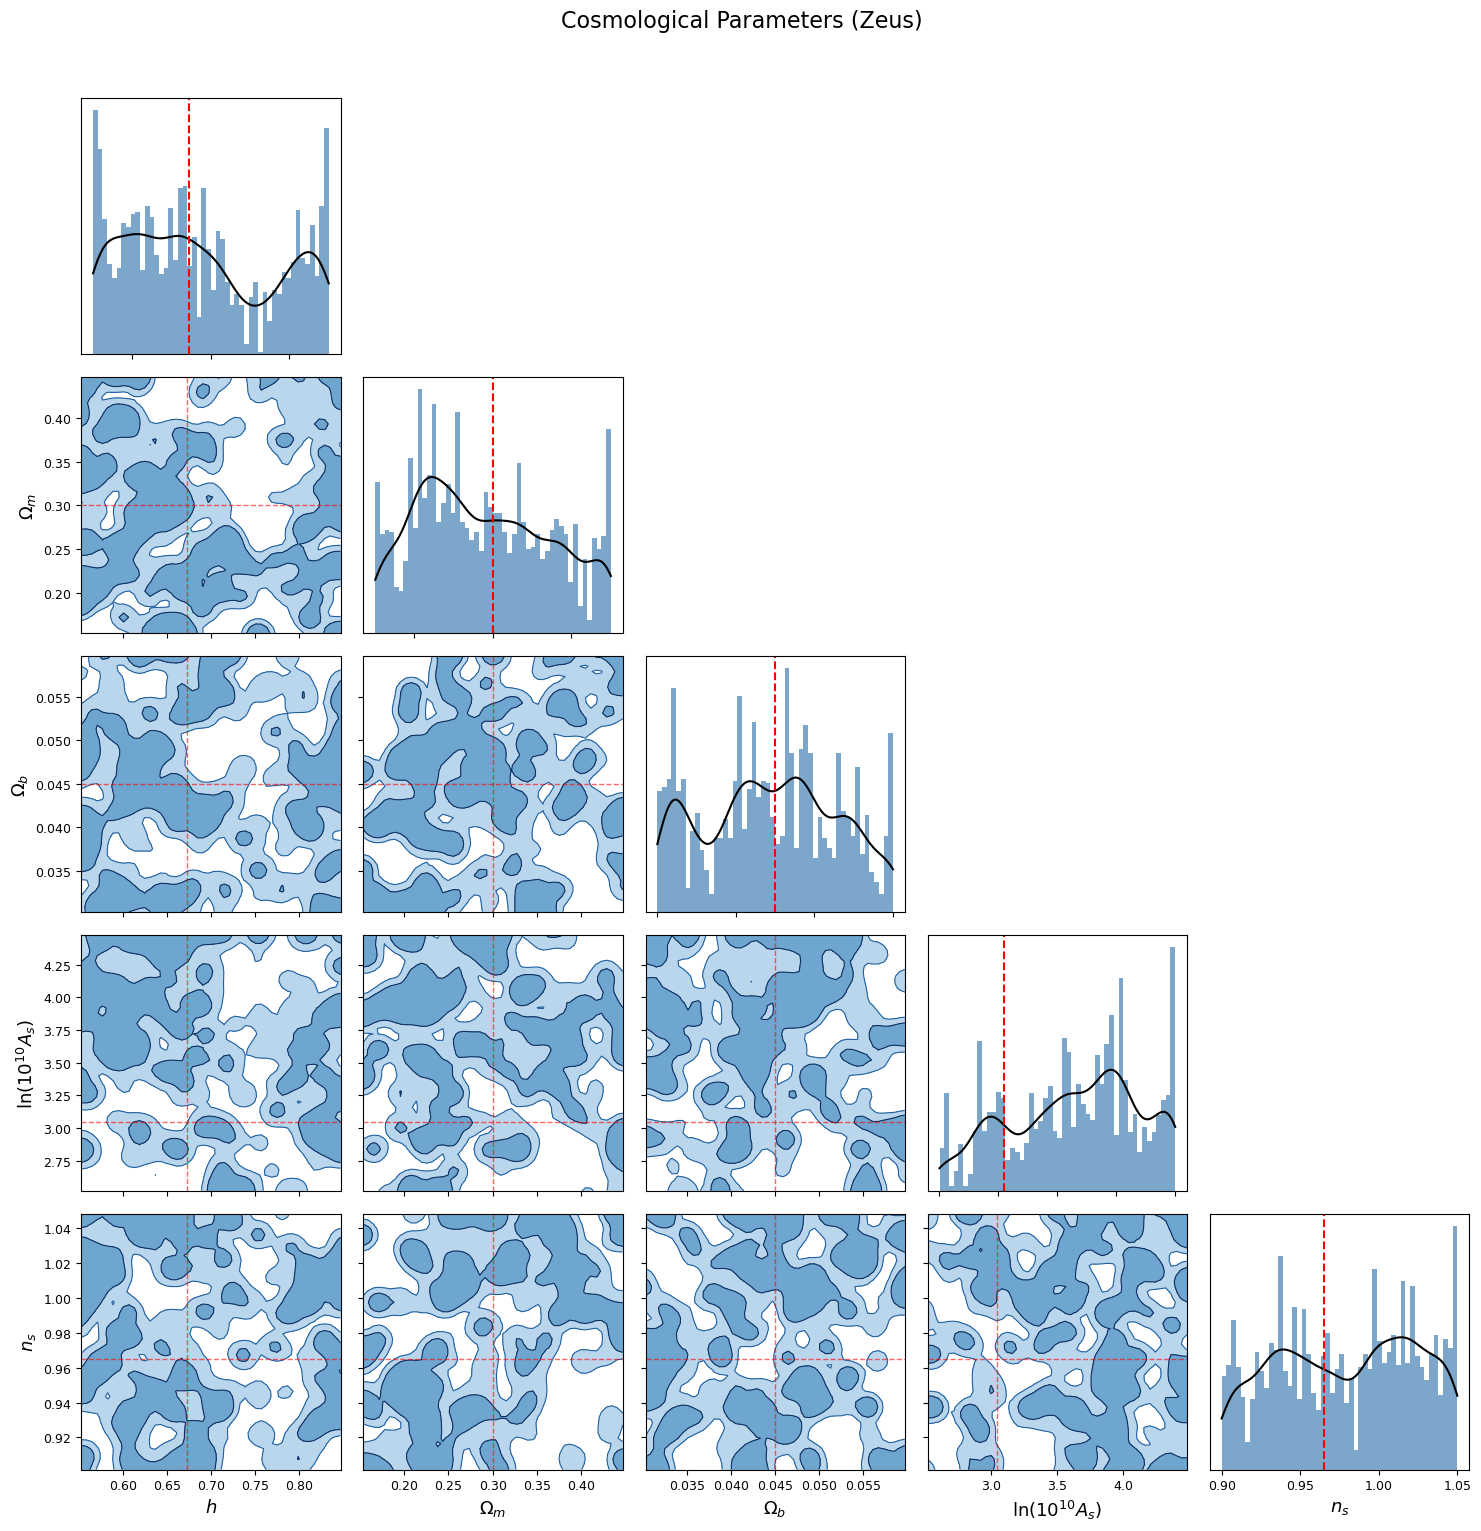

In [11]:
cosmo_samples = samples[:, cosmo_idx]
cosmo_fid = [fiducial[param_names[i]] for i in cosmo_idx]

corner_plot(cosmo_samples, cosmo_labels, fiducial_vals=cosmo_fid,
            title='Cosmological Parameters (Zeus)',
            filename='zeus_corner_cosmo.png')

### 5.2 Mass-Observable Relation (Scaling Relation) Parameters

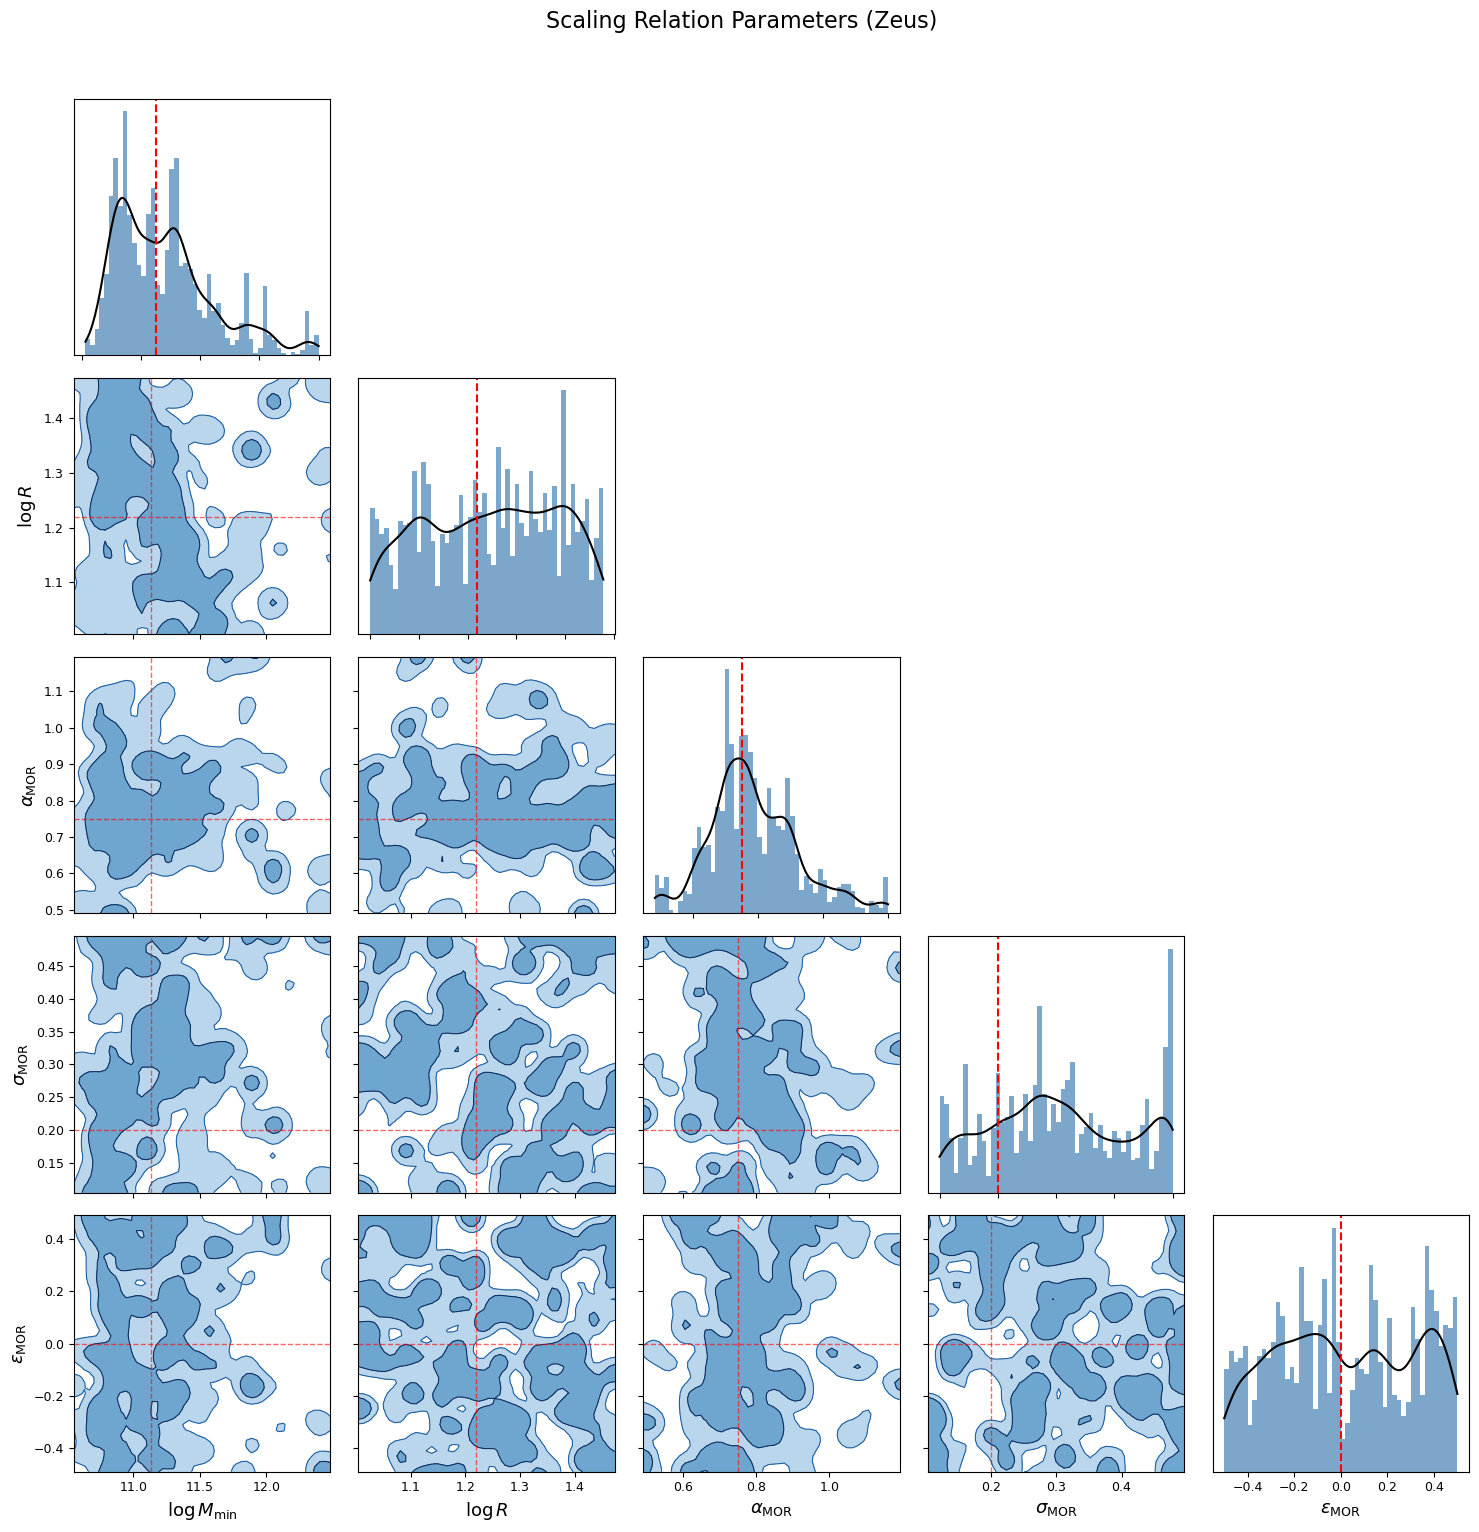

In [12]:
mor_samples = samples[:, mor_idx]
mor_fid = [fiducial[param_names[i]] for i in mor_idx]

corner_plot(mor_samples, mor_labels, fiducial_vals=mor_fid,
            title='Scaling Relation Parameters (Zeus)',
            filename='zeus_corner_mor.png')

## 6. Convergence Summary

In [13]:
print('=' * 70)
print('ZEUS CHAIN CONVERGENCE SUMMARY')
print('=' * 70)
print(f'Total samples: {usable}  |  Walkers: {n_walkers}  |  Steps: {n_steps}')
print(f'Burn-in: {burn_in} steps  |  Post burn-in samples: {samples.shape[0]}')
print()
print(f'{"Parameter":>25s}  {"R-hat":>7s}  {"IAT":>6s}  {"n_eff":>7s}  {"Mean":>10s} +/- {"Std":>10s}')
print('-' * 80)

for i, p in enumerate(param_names):
    rhat = gelman_rubin(chain_post[:, :, i])
    iat = integrated_autocorr_time(samples[:, i])
    n_eff = n_post / iat
    mean = np.mean(samples[:, i])
    std = np.std(samples[:, i])
    print(f'{p:>25s}  {rhat:7.4f}  {iat:6.1f}  {n_eff:7.0f}  {mean:10.5f} +/- {std:10.5f}')

print('-' * 80)
print(f'All R-hat < 1.1: {all(gelman_rubin(chain_post[:, :, i]) < 1.1 for i in range(n_params))}')
print('=' * 70)

ZEUS CHAIN CONVERGENCE SUMMARY
Total samples: 3256  |  Walkers: 44  |  Steps: 74
Burn-in: 14 steps  |  Post burn-in samples: 2640

                Parameter    R-hat     IAT    n_eff        Mean +/-        Std
--------------------------------------------------------------------------------
                       h0   1.2085     1.0     2640     0.68699 +/-    0.09386
                  omega_m   1.2906     1.0     2640     0.29031 +/-    0.08365
                  omega_b   1.2575     1.8     1460     0.04443 +/-    0.00835
                log1e10as   1.3156     1.0     2640     3.64346 +/-    0.54475
                      n_s   1.1773     1.0     2640     0.97929 +/-    0.04406
              mor_logmmin   1.2131     1.0     2640    11.20018 +/-    0.41035
             mor_logratio   1.1967     1.0     2640     1.24611 +/-    0.13624
                mor_alpha   1.2174     1.3     2099     0.78777 +/-    0.13732
                mor_sigma   1.3051     1.0     2640     0.30576 +/-    0.1171

## 7. Pipeline Timing

Parsed from the zeus job log file. Shows the average wall-clock time per pipeline module and per step.

In [14]:
import re
import os

log_file = '../nerscScripts/zeus_preempt-49376130.out'

modules = ['consistency', 'camb', 'mf_tinker', 'halo_model',
           'sigmaCritInv', 'numberCountsMock', 'gammaCent', 'shear', 'likelihoods']

# Parse timing from log (handle encoding errors in large log files)
module_times = {m: [] for m in modules}
total_times = []

with open(log_file, errors='replace') as f:
    for line in f:
        if 'Total pipeline time' in line:
            match = re.search(r'Total pipeline time:\s+([\d.]+)', line)
            if match:
                total_times.append(float(match.group(1)))
        else:
            for m in modules:
                if line.startswith(m + ' took'):
                    match = re.search(r'took:\s+([\d.]+)', line)
                    if match:
                        module_times[m].append(float(match.group(1)))

n_evals = len(total_times)
print(f'Total pipeline evaluations parsed: {n_evals}')
print(f'Total wall time of evaluations: {sum(total_times)/3600:.1f} hours')
print(f'\nAverage pipeline evaluation time: {np.mean(total_times):.2f} s')
print(f'Median pipeline evaluation time:  {np.median(total_times):.2f} s')
print(f'Min / Max: {np.min(total_times):.2f} / {np.max(total_times):.2f} s')

# Per-step time (1 step = n_walkers evaluations run across MPI ranks)
n_ranks = 16  # 4 nodes x 4 ranks/node
evals_per_step = n_walkers
# Each rank runs evals sequentially, so step time ~ (walkers/ranks) * avg_eval_time
step_time_est = (evals_per_step / n_ranks) * np.mean(total_times)
print(f'\nEstimated wall time per step: {step_time_est:.1f} s  ({evals_per_step} walkers / {n_ranks} ranks x {np.mean(total_times):.1f} s/eval)')

Total pipeline evaluations parsed: 320470
Total wall time of evaluations: 767.4 hours

Average pipeline evaluation time: 8.62 s
Median pipeline evaluation time:  9.45 s
Min / Max: 2.03 / 23.10 s

Estimated wall time per step: 23.7 s  (44 walkers / 16 ranks x 8.6 s/eval)


In [15]:
# Average time per module
print('=== Average Time per Module ===')
print(f'{"Module":>20s}  {"Mean (s)":>10s}  {"Median (s)":>10s}  {"% Total":>8s}  {"N evals":>8s}')
print('-' * 65)

total_mean = np.mean(total_times)
for m in modules:
    t = np.array(module_times[m])
    if len(t) > 0:
        pct = np.mean(t) / total_mean * 100
        print(f'{m:>20s}  {np.mean(t):10.4f}  {np.median(t):10.4f}  {pct:7.1f}%  {len(t):>8d}')

print('-' * 65)
print(f'{"TOTAL":>20s}  {total_mean:10.4f}  {np.median(total_times):10.4f}  {"100.0%":>8s}  {n_evals:>8d}')

=== Average Time per Module ===
              Module    Mean (s)  Median (s)   % Total   N evals
-----------------------------------------------------------------
         consistency      0.0000      0.0000      0.0%    320474
                camb      1.7326      1.7090     20.1%    320477


           mf_tinker      0.0765      0.0750      0.9%    320478
          halo_model      0.1703      0.1690      2.0%    320474
        sigmaCritInv      0.0020      0.0020      0.0%    320465
    numberCountsMock      0.3082      0.3410      3.6%    320460
           gammaCent      6.3302      7.1670     73.4%    320470
               shear      0.0010      0.0010      0.0%    320464
         likelihoods      0.0005      0.0010      0.0%    320456
-----------------------------------------------------------------


               TOTAL      8.6211      9.4500    100.0%    320470


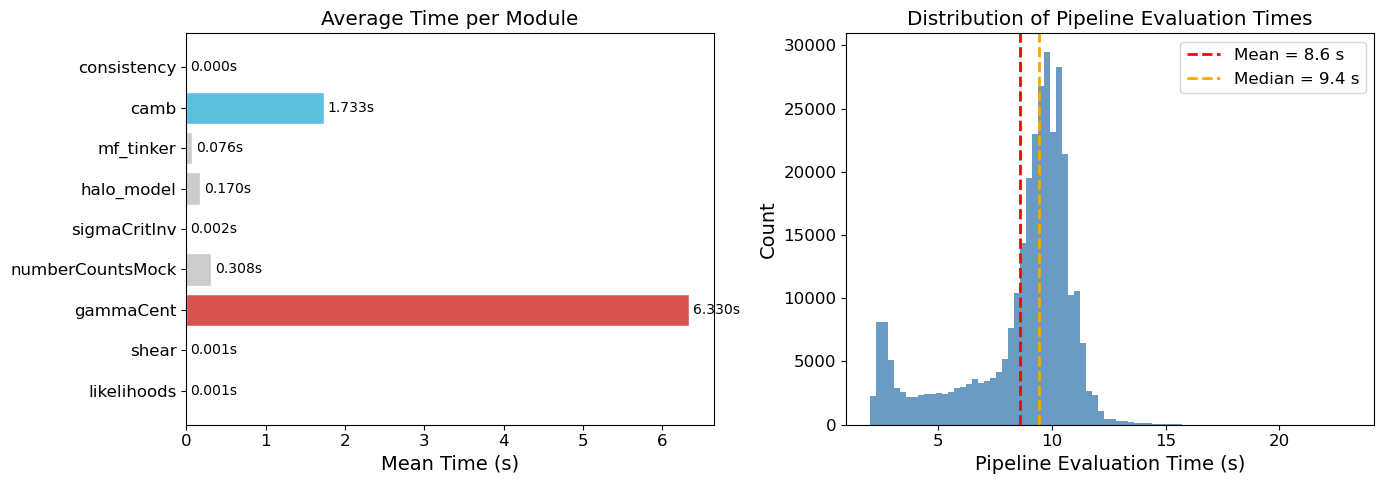

In [16]:
# Bar chart of module timing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of average time per module
means = [np.mean(module_times[m]) for m in modules]
colors = ['#d9534f' if v == max(means) else '#5bc0de' if v == sorted(means)[-2] else '#ccc' for v in means]
ax = axes[0]
bars = ax.barh(modules[::-1], means[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Mean Time (s)')
ax.set_title('Average Time per Module')
for bar, val in zip(bars, means[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}s', va='center', fontsize=10)

# Right: histogram of total pipeline times
ax = axes[1]
ax.hist(total_times, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(np.mean(total_times), color='red', ls='--', lw=2, label=f'Mean = {np.mean(total_times):.1f} s')
ax.axvline(np.median(total_times), color='orange', ls='--', lw=2, label=f'Median = {np.median(total_times):.1f} s')
ax.set_xlabel('Pipeline Evaluation Time (s)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pipeline Evaluation Times')
ax.legend()

plt.tight_layout()
plt.savefig('zeus_pipeline_timing.png', dpi=150, bbox_inches='tight')
plt.show()

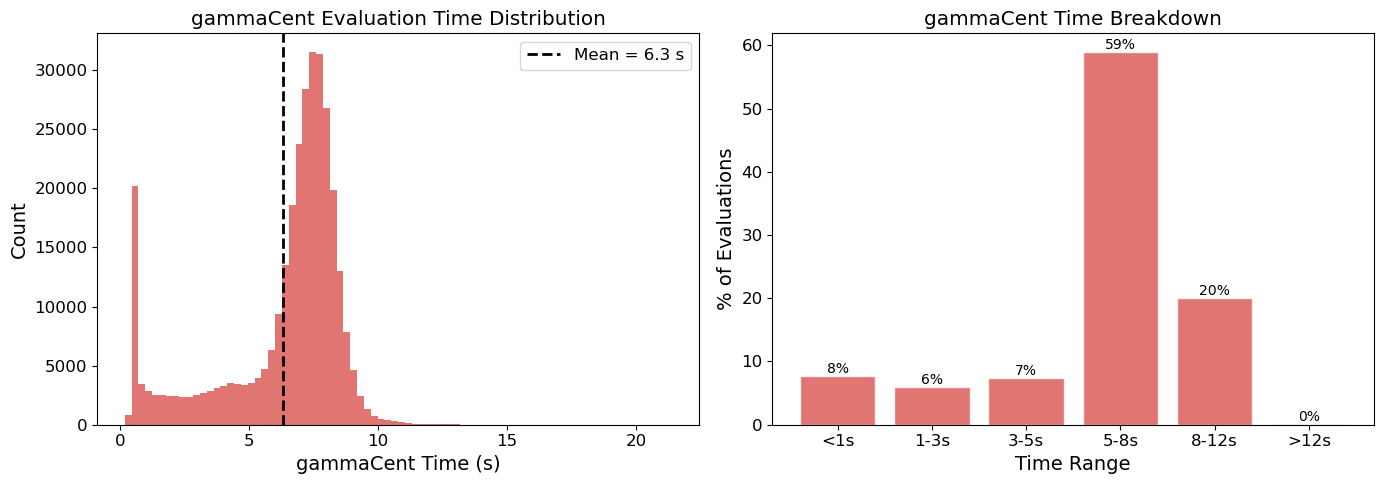

gammaCent takes 73% of total pipeline time


In [17]:
# gammaCent time distribution (dominant bottleneck)
gc_times = np.array(module_times['gammaCent'])
bins_edges = [0, 1, 3, 5, 8, 12, gc_times.max() + 1]
bin_labels = ['<1s', '1-3s', '3-5s', '5-8s', '8-12s', '>12s']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(gc_times, bins=80, color='#d9534f', edgecolor='none', alpha=0.8)
ax.axvline(np.mean(gc_times), color='k', ls='--', lw=2, label=f'Mean = {np.mean(gc_times):.1f} s')
ax.set_xlabel('gammaCent Time (s)')
ax.set_ylabel('Count')
ax.set_title('gammaCent Evaluation Time Distribution')
ax.legend()

ax = axes[1]
counts = [np.sum((gc_times >= lo) & (gc_times < hi)) for lo, hi in zip(bins_edges[:-1], bins_edges[1:])]
pcts = [c / len(gc_times) * 100 for c in counts]
bars = ax.bar(bin_labels, pcts, color='#d9534f', edgecolor='white', alpha=0.8)
for bar, p in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{p:.0f}%', ha='center', fontsize=10)
ax.set_xlabel('Time Range')
ax.set_ylabel('% of Evaluations')
ax.set_title('gammaCent Time Breakdown')

plt.tight_layout()
plt.show()

print(f'gammaCent takes {np.mean(gc_times)/total_mean*100:.0f}% of total pipeline time')